# Klasifikasi Penyakit pada Daun Padi dengan Momen warna, LBP, GLCM, PCA dan SVM

In [19]:
import os
import cv2
import time
import copy
import random
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from skimage import feature
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedGroupKFold, cross_validate, train_test_split, GridSearchCV
from scipy.stats import skew, kurtosis
from sklearn.manifold import TSNE

Ini merupakan beberapa persiapan yang nantinya akan digunakan pada script berikutnya terutama dalam mengatur ukuran dan dataset mana yang nantinya akan dimuat serta penentuan nilai `seed` agar proses randomize dapat dihasilkan kembali dengan hasil yang sama.

In [3]:
IMG_SIZE = (222, 222)
random.seed(42)
np.random.seed(42)
main_dataset_path = 'datasets/local_dataset_no_duplicate'
is_train_splitted = False
LABELS = np.array(os.listdir(f'{main_dataset_path}/train_images')) if is_train_splitted else np.array(os.listdir(main_dataset_path))
MAIN_DATASET = [main_dataset_path, 1400]
DATASETS = [['datasets/paddy-disease-classification-healthy', 1400], ['datasets/rice_leaves_disease', 305]]
AUGMENTATION_TARGET = 5000
N_SPLITS = 5
EXPERIMENT_NAME = '251209 1547 Mixed On Field No Duplicate Normal No Indo'
TEST_IMAGES_PATH = f'datasets/result/{EXPERIMENT_NAME}/test_images'
BLIND_TEST_IMAGES_PATH = f'datasets/result/{EXPERIMENT_NAME}/test_images2'
AUGMENTED_IMAGES_PATH = f'datasets/result/{EXPERIMENT_NAME}/augmented_images'

RESULT_DICT_PATH = f'Results/{EXPERIMENT_NAME}'
Y_TRAIN_PATH = os.path.join(RESULT_DICT_PATH, 'y_train.csv')
Y_TEST_PATH = os.path.join(RESULT_DICT_PATH, 'y_test.csv')
GROUP_TRAIN_PATH = os.path.join(RESULT_DICT_PATH, 'group_train.csv')
SVM_MODEL_PATH = 'optimized_result.pkl'
if not os.path.exists(RESULT_DICT_PATH): os.makedirs(RESULT_DICT_PATH)

In [4]:
def show_class_distribution(labels, title="Class Distribution"):
    """Menampilkan distribusi kelas dalam data label."""
    class_counts = {class_name: labels.count(class_name) for class_name in LABELS}
    
    # Mempersiapkan data untuk plot
    counts = [class_counts[name] for name in LABELS]
    
    # Menampilkan plot
    plt.figure(figsize=(10, 6))
    bars = plt.bar(LABELS, counts, color='blue')
    
    # Menambahkan angka di atas setiap batang
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 5, int(yval), ha='center', va='bottom')
        
    plt.title(title, fontsize=16)
    plt.xlabel("Nama Kelas", fontsize=12)
    plt.ylabel("Jumlah Gambar", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

## Memuat Dataset

Terdapat beberapa dataset yang digunakan seperti Deep Feature, rice_leaves_disease dan paddy_doctor_healthy. Berikut merupakan komposisi dataset yang dimuat pada eksperimen ini.

|Dataset|total kelas|bacterial_leaf_blight|blast|brown_spot|normal|tungro|Total|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|Deep Feature|4|1326|960|1200|0|1308|4794|
|rice_leaves_disease|4|180|305|267|157|0|909|
|Paddy_doctor_healthy|1|0|0|0|1400|0|1400|
|Total|5|1506|1265|1467|1557|1308|7103|

In [5]:
# Load data
def load_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    for folder_name in LABELS:
        data_length = len(data)
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
        print(f"Loaded {len(data)-data_length} images from {folder_name}")
    print('dataset loaded')
    print('dataset len:', len(data))
    print('labels len:', len(labels))
    return np.array(data), np.array(labels)

In [5]:
all_dataset, all_label = load_images_from_directory(MAIN_DATASET[0], MAIN_DATASET[1])

for dataset in DATASETS:
    print(f"Loading additional dataset from {dataset[0]}")
    loaded_dataset, loaded_labels = load_images_from_directory(dataset[0], dataset[1])
    all_dataset = np.concatenate((all_dataset, loaded_dataset), axis=0)
    all_label = np.concatenate((all_label, loaded_labels), axis=0)

print('extra dataset loaded')
print('dataset shape:', all_dataset.shape)
print('labels shape:', all_label.shape)

1326 images in bacterial_leaf_blight
Loaded 1326 images from bacterial_leaf_blight
960 images in blast
Loaded 960 images from blast
1200 images in brown_spot
Loaded 1200 images from brown_spot
0 images in normal
Loaded 0 images from normal
1308 images in tungro
Loaded 1308 images from tungro
dataset loaded
dataset len: 4794
labels len: 4794
Loading additional dataset from datasets/paddy-disease-classification-healthy
Directory not found: datasets/paddy-disease-classification-healthy\bacterial_leaf_blight
Directory not found: datasets/paddy-disease-classification-healthy\blast
Directory not found: datasets/paddy-disease-classification-healthy\brown_spot
1764 images in normal
Loaded 1400 images from normal
Directory not found: datasets/paddy-disease-classification-healthy\tungro
dataset loaded
dataset len: 1400
labels len: 1400
Loading additional dataset from datasets/rice_leaves_disease
180 images in bacterial_leaf_blight
Loaded 180 images from bacterial_leaf_blight
305 images in blast


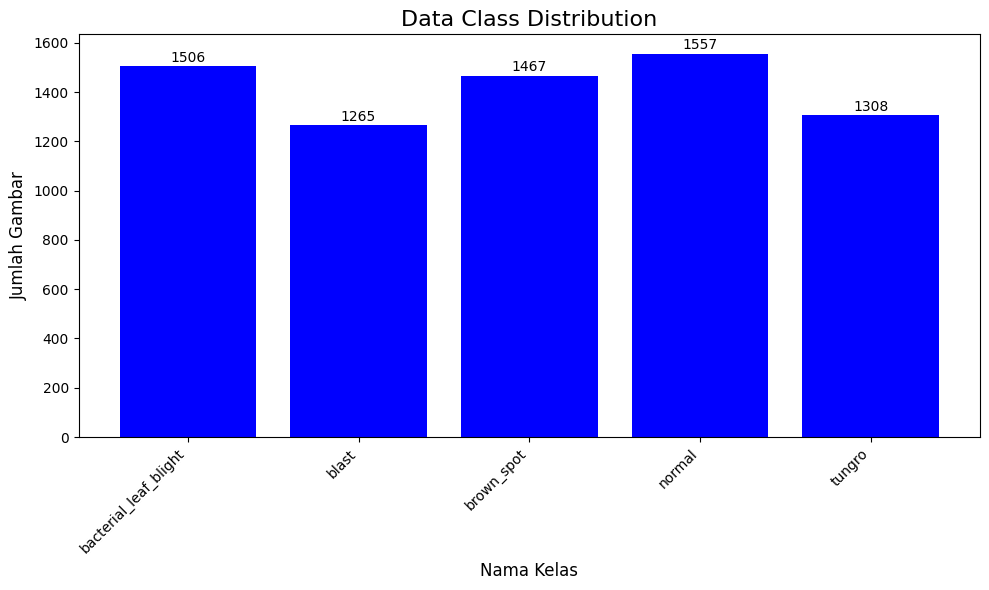

In [6]:
show_class_distribution(all_label.tolist(), title="Data Class Distribution")

In [7]:
permutation_indices = np.random.permutation(len(all_dataset))
all_dataset = all_dataset[permutation_indices]
all_label = all_label[permutation_indices]

Seluruh dataset telah dimuat menjadi satu kumpulan data baik data citra dan juga label/kelas dari masing-masing data tersebut. Dari Diagram tersebut terlihat bahwa terjadi unbalanced/ketidakseimbangan antar kelas baik penyakit maupun yang sehat.
Berikutnya adalah proses Preprocessing yang sebelumnya sudah diterapkan yaitu `resize` pada fungsi `load_images_from_directory()` menjadi sesuai dengan ukuran yang terdapat pada variabel `IMG_SIZE` yaitu dengan ukuran 222X222.

## Preprocessing
Pada tahap ini dataset yang sudah dikumpulkan dan dimuat akan di-preprocessing. Terdapat beberapa tahapan yang dilakukan pada preprocessing ini, seperti:
1. pembagian dataset menjadi data training dan validation dengan data testing
2. augmentasi pada data training dan validation
3. normalisasi citra menggunakan CLAHE pada channel L dari color space LAB
4. Konversi dataset yang sudah dinormalisasi ke color space Grayscale, HSV dan LAB

### Pembagian Dataset
Pembagian dataset dilakukan untuk membagi dataset menjadi 2 yaitu dataset training dan validasi dengan data testing. Data Testing akan memiliki jumlah yang seimbang yaitu di 200 gambar/kelas sehingga totalnya ada 1000 gambar, sedangkan untuk data training adalah sisanya. Data Testing akan digunakan untuk pengujian terakhir pada model dengan performa dan efisiensi terbaik.
Berikut hasil pembagian data training dan validasi dengan data testing.

In [10]:
def split_dataset_by_class(dataset, labels, num_test_per_class):
    """
    Splits the dataset into training and testing sets with a fixed number
    of test samples per class.

    Args:
        dataset (np.ndarray): The feature data of the entire dataset.
        labels (np.ndarray): The labels of the entire dataset.
        num_test_per_class (int): The fixed number of test samples for each class.

    Returns:
        tuple: A tuple containing X_train, X_test, y_train, y_test.
    """
    print(f"--- Splitting dataset with a fixed test size of {num_test_per_class} per class ---")
    
    # Get unique classes and their indices
    # unique_classes = np.unique(LABELS)
    
    # Initialize lists to store the split data
    X_train_list, X_test_list = [], []
    y_train_list, y_test_list = [], []
    
    # Iterate through each unique class
    for label in LABELS:
        # Find the indices of samples belonging to the current class
        class_indices = np.where(labels == label)[0]
        class_dataset = dataset[class_indices]
        class_labels = labels[class_indices]
        
        # Check if the class has enough samples for the test set
        if len(class_dataset) < num_test_per_class:
            print(f"Warning: Class {label} has fewer than {num_test_per_class} samples. It will be entirely used for testing.")
            # Use all samples for testing if not enough
            X_test_list.append(class_dataset)
            y_test_list.append(class_labels)
            
        else:
            # Perform a stratified split for the current class
            X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
                class_dataset,
                class_labels,
                test_size=num_test_per_class,
                random_state=42,
                stratify=class_labels
            )
            
            # Append the results to the lists
            X_train_list.append(X_train_class)
            X_test_list.append(X_test_class)
            y_train_list.append(y_train_class)
            y_test_list.append(y_test_class)
    
    # Concatenate the split data from all classes
    X_train = np.concatenate(X_train_list, axis=0)
    X_test = np.concatenate(X_test_list, axis=0)
    y_train = np.concatenate(y_train_list, axis=0)
    y_test = np.concatenate(y_test_list, axis=0)
    
    return X_train, X_test, y_train, y_test

--- Splitting dataset with a fixed test size of 200 per class ---


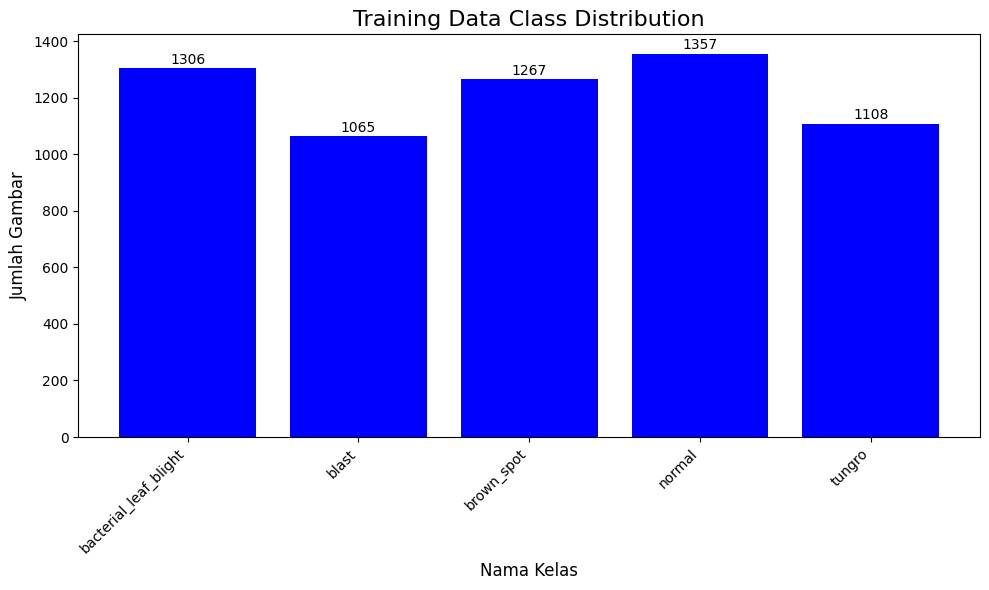

In [11]:
X_train, X_test, y_train, y_test = split_dataset_by_class(all_dataset, all_label, num_test_per_class=200)
train_group_id = np.arange(len(X_train))
show_class_distribution(y_train.tolist(), title="Training Data Class Distribution")

|Segment|bacterial_leaf_blight|blast|brown_spot|normal|tungro|Total|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|Train|1306|1065|1267|1357|1108|6103|
|Test|200|200|200|200|200|1000|
|total|1506|1265|1467|1557|1308|7103|

In [16]:
# Save test data from splitted dataset
def save_data(X, y, output_dir):
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    for i, (image, label) in enumerate(zip(X, y)):
        if not os.path.exists(f"{output_dir}/{label}"):
            os.makedirs(f"{output_dir}/{label}")
        image_path = os.path.join(output_dir, f"{label}/{label}_{i}.jpg")
        cv2.imwrite(image_path, image)
        
save_data(X_test, y_test, TEST_IMAGES_PATH)

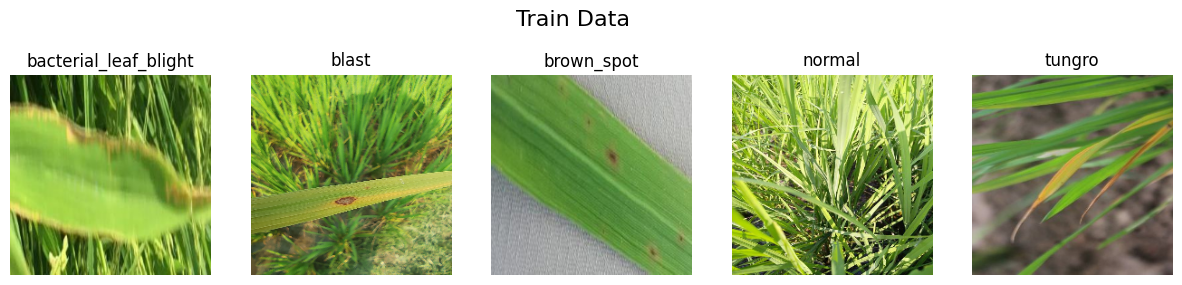

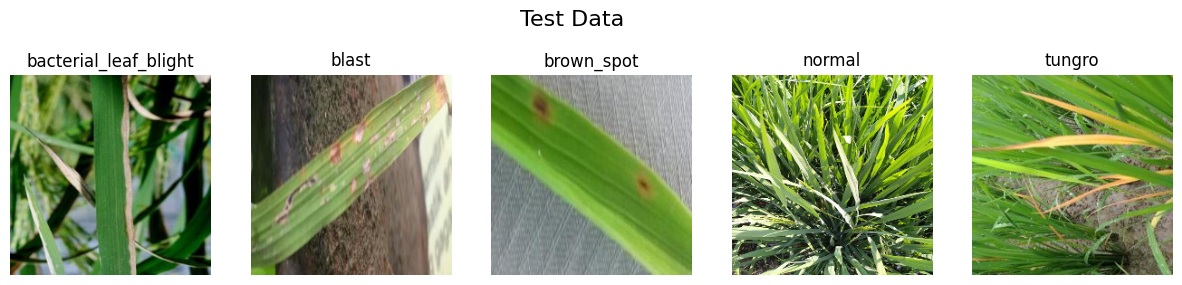

In [10]:
fig = plt.figure(figsize=(15, 6))

fig.suptitle('Train Data', fontsize=16)

if len(LABELS) < 5: cols = len(LABELS)
else: cols = 5

row = (len(LABELS) // 5)+1

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_train == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_train[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])


fig = plt.figure(figsize=(15, 6))

fig.suptitle('Test Data', fontsize=16)

for j in range(len(LABELS)):
    fig.add_subplot(row, cols, j+1)
    index = np.where(y_test == LABELS[j])[0][0]
    plt.imshow(cv2.cvtColor(X_test[index], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(LABELS[j])

### Augmentasi data training dan validasi
Augmentasi dilakukan untuk menyeimbangkan jumlah gambar dari masing-masing kelas. Augmentasi yang dilakukan terdiri dari augmentasi warna seperti brightness contrast dan gamma untuk memberikan sedikit variasi dan juga augmentasi geometri seperti flip dan rotation. Target jumlah gambar training dan validasi yang sudah diaugmentasi yaitu 5000 gambar. Agar dapat memenuhi target tersebut, maka setiap gambar akan dipilih secara acak untuk diaugmentasi lebih banyak dibandingkan yang lainnya (oversampling). Selain itu, untuk mencegah terjadinya kebocoran data antara data training dan validasi, maka setiap gambar akan diberi grup antara yang asli dengan hasil augmentasinya, sehingga hasil augmentasi tidak terpisah dengan gambar asli dan masuk di bagian yang berbeda baik training maupun validasi.

In [6]:
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    # Menggunakan BORDER_REPLICATE untuk mengisi piksel kosong dengan piksel tepi terdekat
    rotated = cv2.warpAffine(image, M, (w, h), borderMode=cv2.BORDER_REPLICATE)
    return rotated

In [7]:
def get_balancer_amount(max_amount):
    return {f'{class_name}': max_amount-y_train.tolist().count(class_name) for class_name in LABELS}

In [8]:
def augment_images(X, y):
    augment_pool = ['flip_h', 'flip_v', 'rot90', 'rot180', 'rot270']
    balancer_amount = get_balancer_amount(AUGMENTATION_TARGET)
    
    augmented_group_id = []
    augmented_images = []
    augmented_labels = []
    
    for class_name, amount in balancer_amount.items():
        write_path = f"{AUGMENTED_IMAGES_PATH}/{class_name}/"
        os.makedirs(f'{write_path}', exist_ok=True)
        
        indices = np.where(y == class_name)[0]
        original_images = X[indices]
    
        shuffled_number = np.random.permutation(len(original_images))
        shuffled_images = original_images[shuffled_number]
        shuffled_indices = indices[shuffled_number]
        
        original_len = y_train.tolist().count(class_name)
        augmentation_len = amount//original_len
        remainder_data = amount%original_len

        for i, img in enumerate(shuffled_images):
            
            # Pilih fungsi augmentasi secara acak
            if i < remainder_data: chosen_aug = random.sample(augment_pool, augmentation_len+1)
            else: chosen_aug = random.sample(augment_pool, augmentation_len)
            
            for augmentation in chosen_aug:
                if augmentation == 'flip_h': augmented_image = cv2.flip(img.copy(), 1)
                elif augmentation == 'flip_v': augmented_image = cv2.flip(img.copy(), 0)
                elif augmentation == 'rot90': augmented_image = rotate_image(img.copy(), 90)
                elif augmentation == 'rot180': augmented_image = rotate_image(img.copy(), 180)
                elif augmentation == 'rot270': augmented_image = rotate_image(img.copy(), -90)

                # Tambahkan hasil ke list
                augmented_images.append(augmented_image)
                augmented_group_id.append(shuffled_indices[i])
                augmented_labels.append(class_name)
                cv2.imwrite(f"{write_path}/{shuffled_indices[i]}_augmented_{augmentation}.jpg", augmented_image)
                
    return np.array(augmented_images), np.array(augmented_labels), np.array(augmented_group_id)

In [25]:
augmented_x_train, augmented_y_train, augmented_group_id = augment_images(X_train, y_train)

In [12]:
# Load data with group id
def load_augmented_images_from_directory(base_path, limit=1000):
    data = []
    labels = []
    group_id = []
    for folder_name in LABELS:
        data_length = len(data)
        folder_path = os.path.join(base_path, folder_name)
        if not os.path.exists(folder_path):
            print(f"Directory not found: {folder_path}")
            continue
        
        print(len(os.listdir(folder_path)), "images in", folder_name)
        for i, filename in enumerate(os.listdir(folder_path)):
            if i == limit: break
            image_path = os.path.join(folder_path, filename)
            img = cv2.imread(image_path)
            if img is None:
                print(f"Failed to load image: {image_path}")
                continue

            data.append(cv2.resize(img, IMG_SIZE))
            labels.append(folder_name)
            group_id.append(int(filename.split("_")[0]))
        print(f"Loaded {len(data)-data_length} images from {folder_name}")
    print('dataset loaded') 
    print('dataset len:', len(data))
    print('labels len:', len(labels))
    return np.array(data), np.array(labels), np.array(group_id)

# used to load the augmented images without augmenting from scratch again
augmented_x_train, augmented_y_train, augmented_group_id = load_augmented_images_from_directory(AUGMENTED_IMAGES_PATH, AUGMENTATION_TARGET)

3694 images in bacterial_leaf_blight
Loaded 3694 images from bacterial_leaf_blight
3935 images in blast
Loaded 3935 images from blast
3733 images in brown_spot
Loaded 3733 images from brown_spot
3643 images in normal
Loaded 3643 images from normal
3892 images in tungro
Loaded 3892 images from tungro
dataset loaded
dataset len: 18897
labels len: 18897


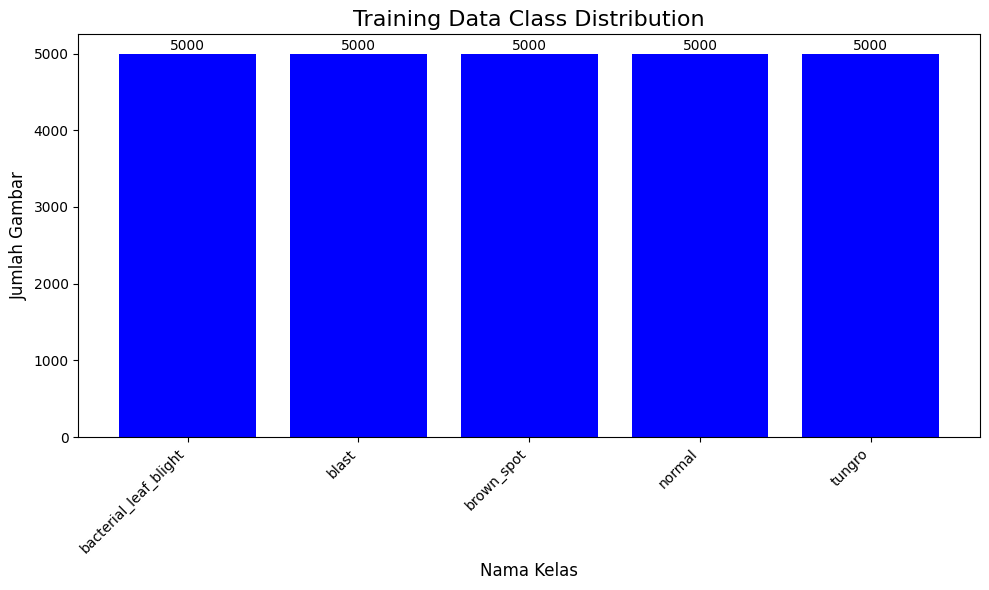

In [13]:
train_group_id = np.append(train_group_id, augmented_group_id)
X_train = np.append(X_train, augmented_x_train, axis=0)
y_train = np.append(y_train, augmented_y_train)
show_class_distribution(y_train.tolist(), title="Training Data Class Distribution")

|Data|bacterial_leaf_blight|blast|brown_spot|normal|tungro|Total|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
|Real|1306|1065|1267|1357|1108|6103|
|Augment|3694|3935|3733|3643|3892|18897|
|total|5000|5000|5000|5000|5000|25000|

In [14]:
pd.DataFrame(y_train).to_csv(Y_TRAIN_PATH, index=False)
pd.DataFrame(y_test).to_csv(Y_TEST_PATH, index=False)
pd.DataFrame(train_group_id).to_csv(GROUP_TRAIN_PATH, index=False)

In [9]:
y_train = pd.read_csv(Y_TRAIN_PATH).to_numpy().ravel()
y_test = pd.read_csv(Y_TEST_PATH).to_numpy().ravel()
train_group_id = pd.read_csv(GROUP_TRAIN_PATH).to_numpy().ravel()

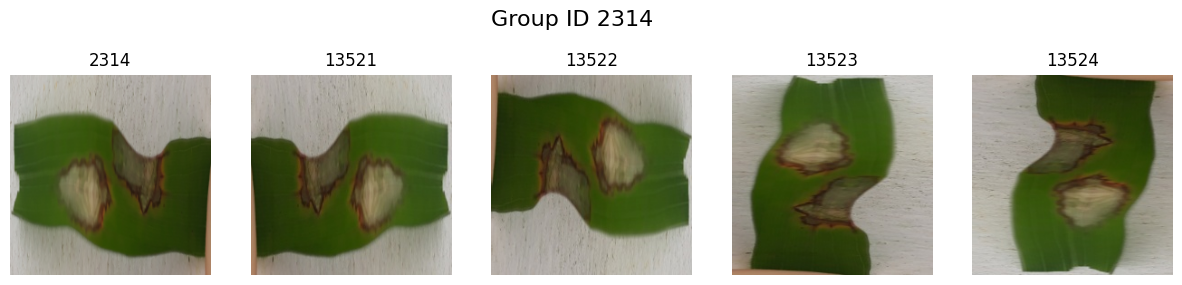

In [16]:
first_group_id_indices = np.where(train_group_id == 2314)[0]

if len(first_group_id_indices) < 5:
    cols = len(first_group_id_indices)
    row = 2
else:
    cols = 5
    row = (len(first_group_id_indices) // 5)+1

fig = plt.figure(figsize=(3*cols, 3*row))
fig.suptitle("Group ID 2314", fontsize=16)

for i, j in enumerate(first_group_id_indices):
    fig.add_subplot(row, cols, i+1)
    plt.imshow(cv2.cvtColor(X_train[j], cv2.COLOR_BGR2RGB))
    plt.axis('off') 
    plt.title(j)

### Normalisasi Citra
Kesesluruhan data saat ini siap untuk diekstrak fiturnya, namun agar warna citra tersebut dapat lebih stabil dengan tingkat pencahayaan yang berbeda baik saat pagi, siang, maupun sore, maka digunakan normalisasi dengan CLAHE yang dapat melakukan normalisasi secara lokal. Metode ini diterapkan pada channel L pada color space LAB citra tersebut.

In [10]:
def normalizer(image, clahe):
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab_image)
    
    normalized_l = clahe.apply(l_channel)
    return cv2.cvtColor(cv2.merge((normalized_l, a_channel, b_channel)), cv2.COLOR_LAB2RGB)

In [11]:
def dataset_normalizer(dataset):
    normalized_images = []
    
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    for image in dataset: normalized_images.append(normalizer(image, clahe))

    return np.array(normalized_images)

In [21]:
normalized_X_train = dataset_normalizer(X_train)
normalized_X_test = dataset_normalizer(X_test)

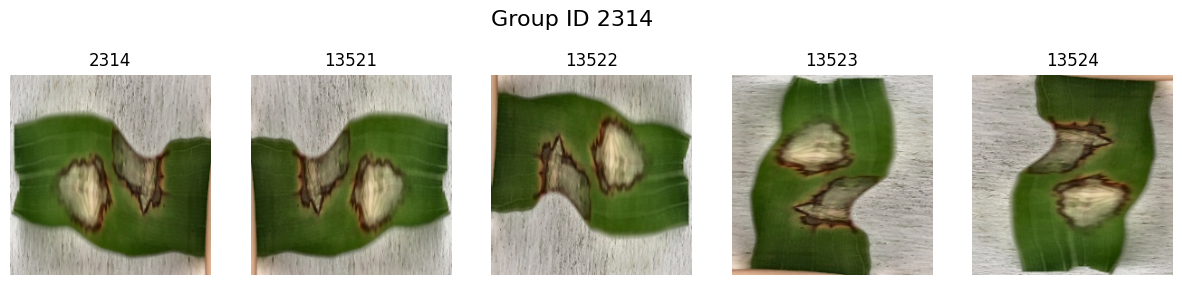

In [22]:
first_group_id_indices = np.where(train_group_id == 2314)[0]

if len(first_group_id_indices) < 5:
    cols = len(first_group_id_indices)
    row = 2
else:
    cols = 5
    row = (len(first_group_id_indices) // 5)+1

fig = plt.figure(figsize=(3*cols, 3*row))
fig.suptitle("Group ID 2314", fontsize=16)

for i, j in enumerate(first_group_id_indices):
    fig.add_subplot(row, cols, i+1)
    plt.imshow(normalized_X_train[j])
    plt.axis('off') 
    plt.title(j)

## Ekstraksi Fitur
Ektraksi fitur memungkinkan citra yang masih mentah menjadi kumpulan vektor yang lebih kecil namun bisa memberikan representasi citra yang akurat. Fitur yang akan digunakan terdiri dari fitur warna dan tekstur. Fitur warna yang digunakan yaitu momen warna dari 2 color space yaitu HSV dan LAB, sedangkan fitur tekstur menggunakan LBP dan GLCM.

In [12]:
def calculate_color_moments(image):
    moments = []
            
    ch1, ch2, ch3 = cv2.split(image)
    for channel in [ch1, ch2, ch3]:
        moments.append(channel[np.nonzero(channel)].mean())
        moments.append(channel[np.nonzero(channel)].std())
        moments.append(skew(channel.reshape(-1)))
        moments.append(kurtosis(channel.reshape(-1)))
    
    return np.array(moments)

In [13]:
def calculate_glcm(gray):
    glcm = feature.graycomatrix(gray, distances=[8], angles=[0], symmetric=True, normed=True)
    contrast = feature.graycoprops(glcm, 'contrast')
    energy = feature.graycoprops(glcm, 'energy')
    homogeneity = feature.graycoprops(glcm, 'homogeneity')
    correlation = feature.graycoprops(glcm, 'correlation')
    dissimilarity = feature.graycoprops(glcm, 'dissimilarity')
    
    return np.concatenate((contrast.flatten(), energy.flatten(), homogeneity.flatten(), correlation.flatten(), dissimilarity.flatten()))

def calculate_lbp(gray):
    P = 16
    lbp = feature.local_binary_pattern(gray, P, R=2, method='uniform')
    # uniform_n_bins = P*(P-1)+3
    # hist_lbp, _ = np.histogram(lbp, bins=np.arange(0, uniform_n_bins+1), range=(0, uniform_n_bins))
    
    uniform_n_bins = int(lbp.max() + 1)
    hist_lbp, _ = np.histogram(lbp.ravel(), density=True, bins=uniform_n_bins, range=(0, uniform_n_bins))
    return np.array(hist_lbp)

In [14]:
def feature_extraction(dataset, func, csv_path, color_code):
    feature = []
    for img in dataset:
        feature.append(func(cv2.cvtColor(img, color_code)))
    
    pd_feature = pd.DataFrame(feature)
    pd_feature.to_csv(csv_path, index=False)
    return pd_feature.to_numpy()

In [26]:
momen_X_train_HSV = feature_extraction(normalized_X_train, calculate_color_moments, os.path.join(RESULT_DICT_PATH, 'momen_hsv_train.csv'), cv2.COLOR_RGB2HSV)
momen_X_test_HSV = feature_extraction(normalized_X_test, calculate_color_moments, os.path.join(RESULT_DICT_PATH, 'momen_hsv_test.csv'), cv2.COLOR_RGB2HSV)
momen_X_train_LAB = feature_extraction(normalized_X_train, calculate_color_moments, os.path.join(RESULT_DICT_PATH, 'momen_lab_train.csv'), cv2.COLOR_RGB2LAB)
momen_X_test_LAB = feature_extraction(normalized_X_test, calculate_color_moments, os.path.join(RESULT_DICT_PATH, 'momen_lab_test.csv'), cv2.COLOR_RGB2LAB)
X_train_LBP = feature_extraction(normalized_X_train, calculate_lbp, os.path.join(RESULT_DICT_PATH, 'lbp_train.csv'), cv2.COLOR_RGB2GRAY)
X_test_LBP = feature_extraction(normalized_X_test, calculate_lbp, os.path.join(RESULT_DICT_PATH, 'lbp_test.csv'), cv2.COLOR_RGB2GRAY)
X_train_GLCM = feature_extraction(normalized_X_train, calculate_glcm, os.path.join(RESULT_DICT_PATH, 'glcm_train.csv'), cv2.COLOR_RGB2GRAY)
X_test_GLCM = feature_extraction(normalized_X_test, calculate_glcm, os.path.join(RESULT_DICT_PATH, 'glcm_test.csv'), cv2.COLOR_RGB2GRAY)

In [15]:
momen_X_train_HSV = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'momen_hsv_train.csv'))
momen_X_test_HSV = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'momen_hsv_test.csv'))
momen_X_train_LAB = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'momen_lab_train.csv'))
momen_X_test_LAB = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'momen_lab_test.csv'))
X_train_LBP = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'lbp_train.csv'))
X_test_LBP = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'lbp_test.csv'))
X_train_GLCM = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'glcm_train.csv'))
X_test_GLCM = pd.read_csv(os.path.join(RESULT_DICT_PATH, 'glcm_test.csv'))

In [16]:
color_feature_X_train = pd.concat([momen_X_train_HSV, momen_X_train_LAB], axis=1)
texture_feature_X_train = pd.concat([X_train_LBP, X_train_GLCM], axis=1)
all_feature_X_train = pd.concat([color_feature_X_train, texture_feature_X_train], axis=1)

color_feature_X_test = pd.concat([momen_X_test_HSV, momen_X_test_LAB], axis=1)
texture_feature_X_test = pd.concat([X_test_LBP, X_test_GLCM], axis=1)
all_feature_X_test = pd.concat([color_feature_X_test, texture_feature_X_test], axis=1)

In [17]:
print(momen_X_train_HSV.shape, momen_X_test_HSV.shape, momen_X_train_LAB.shape, momen_X_test_LAB.shape, X_train_LBP.shape, X_test_LBP.shape, X_train_GLCM.shape, X_test_GLCM.shape)

(25000, 12) (1000, 12) (25000, 12) (1000, 12) (25000, 18) (1000, 18) (25000, 5) (1000, 5)


In [18]:
color_feature_X_train.columns = range(len(color_feature_X_train.columns))
texture_feature_X_train.columns = range(len(texture_feature_X_train.columns))
all_feature_X_train.columns = range(len(all_feature_X_train.columns))

color_feature_X_test.columns = range(len(color_feature_X_test.columns))
texture_feature_X_test.columns = range(len(texture_feature_X_test.columns))
all_feature_X_test.columns = range(len(all_feature_X_test.columns))

In [22]:
def data_visualizer(data, labels, title):
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    lda_pre = LDA(n_components=2) # Kurangi ke 50 dimensi dulu
    data_lda = lda_pre.fit_transform(data_scaled, labels)

    # 4. Visualisasi
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=data_lda[:,0], y=data_lda[:,1], hue=labels, palette='viridis')
    plt.title(title)
    plt.show()

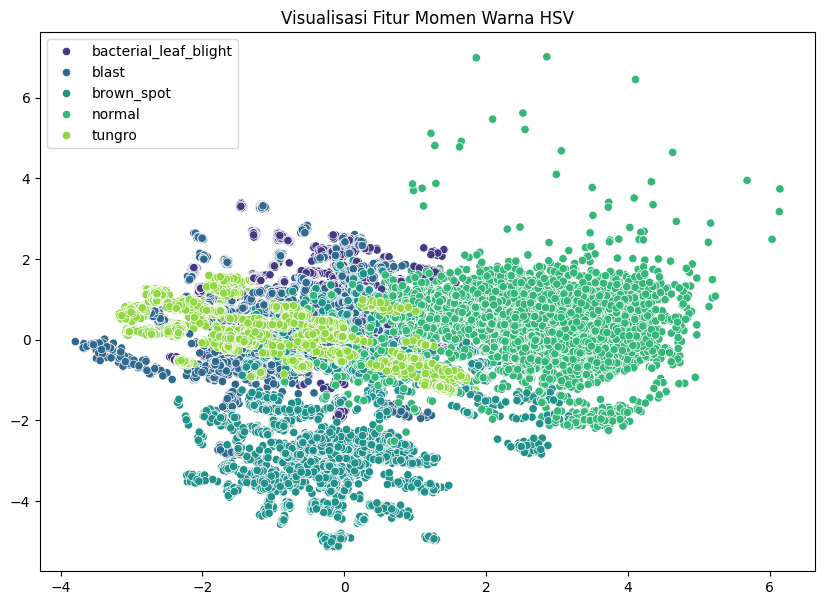

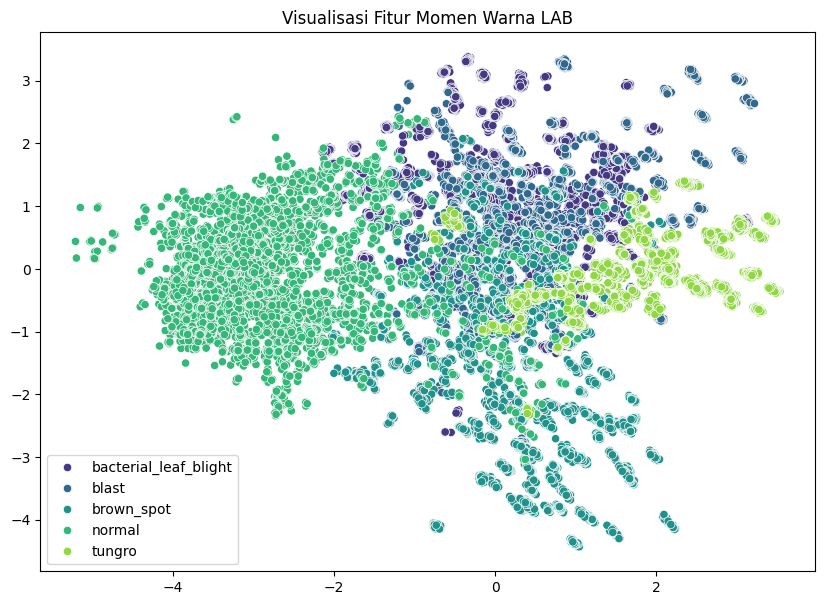

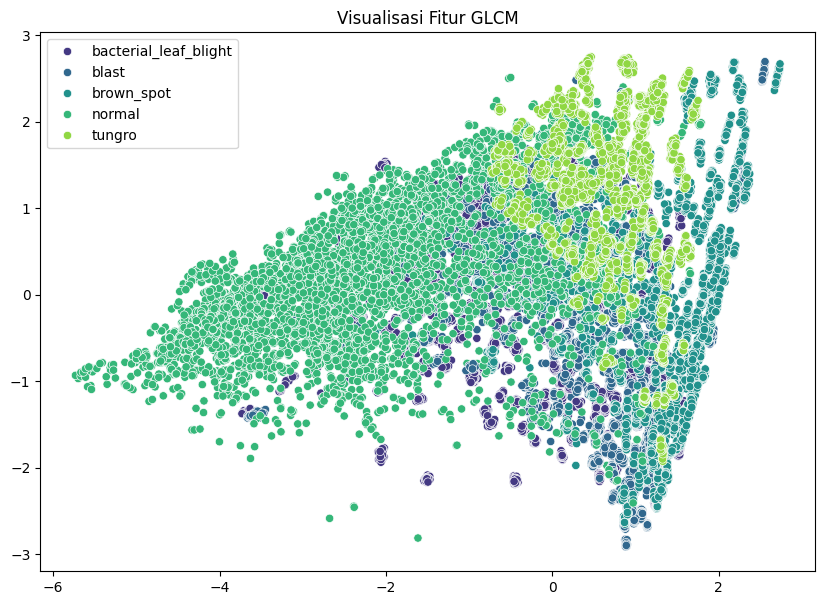

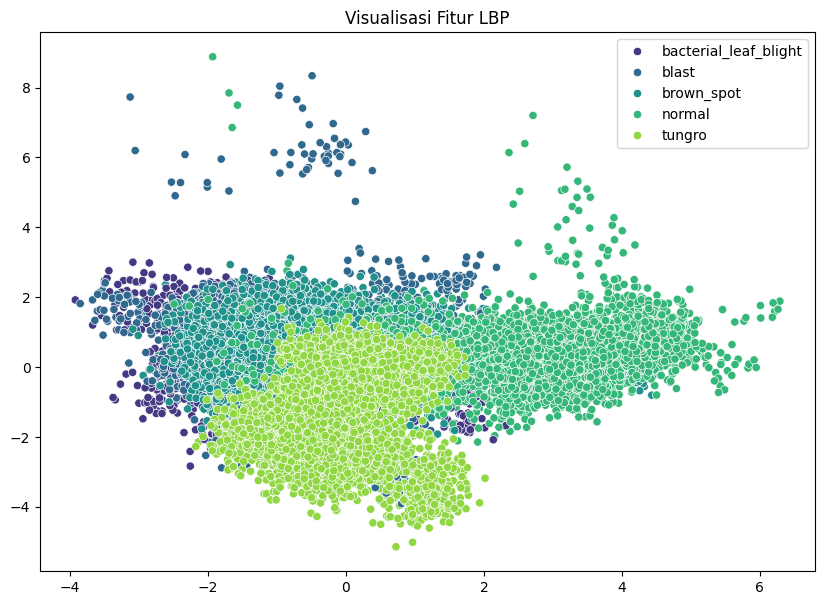

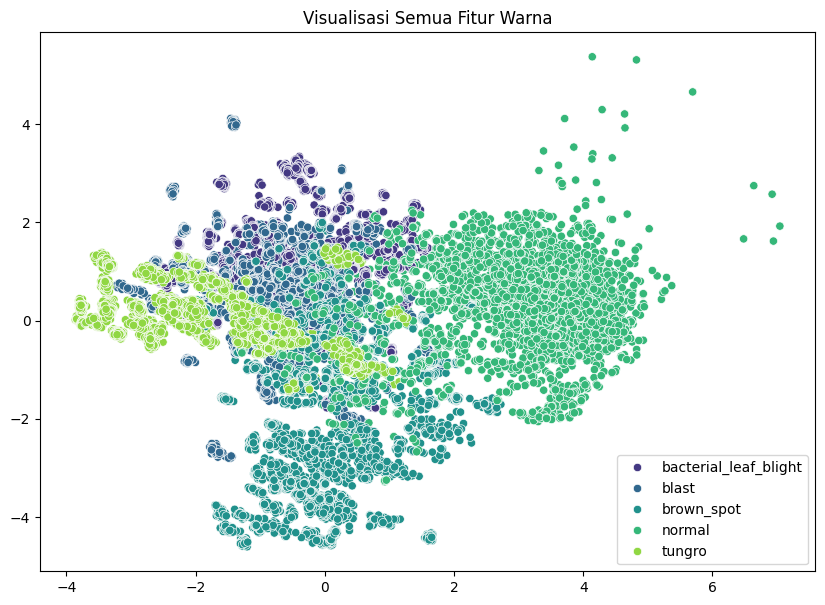

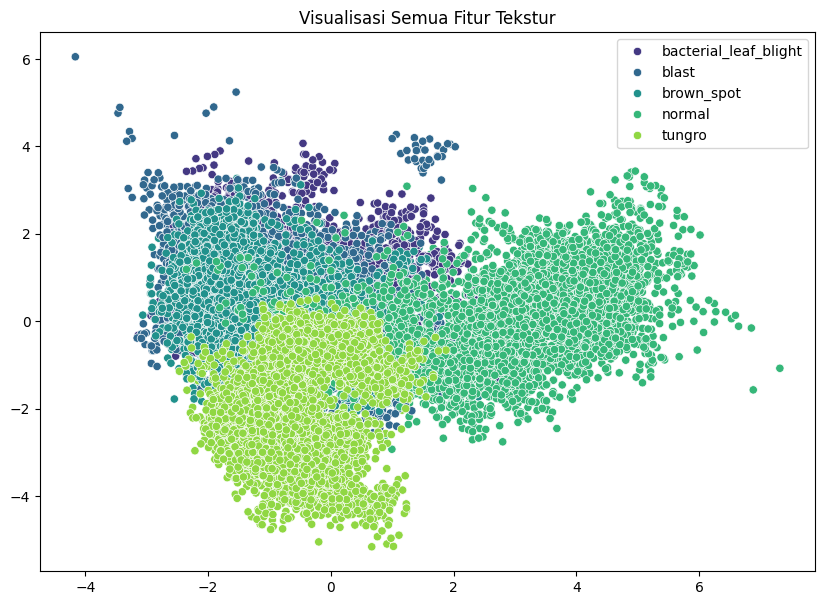

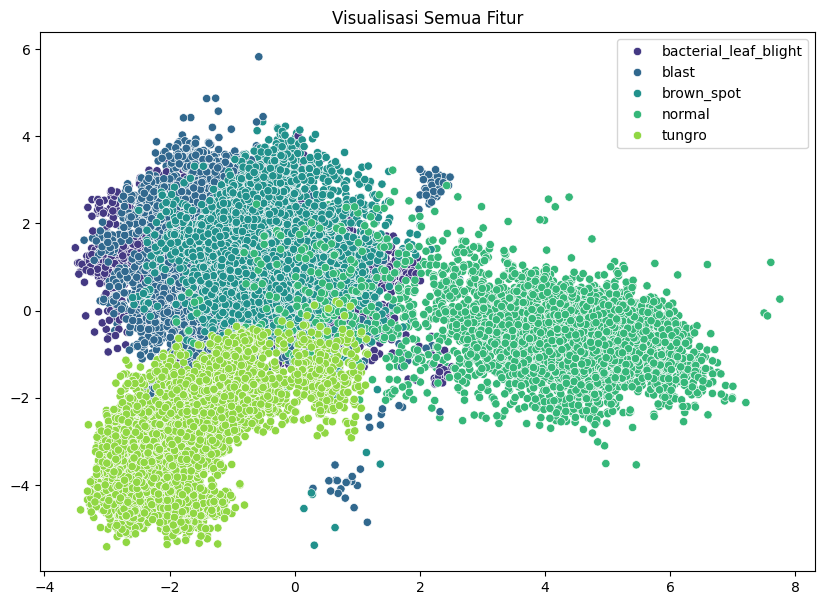

In [23]:
data_visualizer(momen_X_train_HSV, y_train, "Visualisasi Fitur Momen Warna HSV")
data_visualizer(momen_X_train_LAB, y_train, "Visualisasi Fitur Momen Warna LAB")
data_visualizer(X_train_GLCM, y_train, "Visualisasi Fitur GLCM")
data_visualizer(X_train_LBP, y_train, "Visualisasi Fitur LBP")
data_visualizer(color_feature_X_train, y_train, "Visualisasi Semua Fitur Warna")
data_visualizer(texture_feature_X_train, y_train, "Visualisasi Semua Fitur Tekstur")
data_visualizer(all_feature_X_train, y_train, "Visualisasi Semua Fitur")

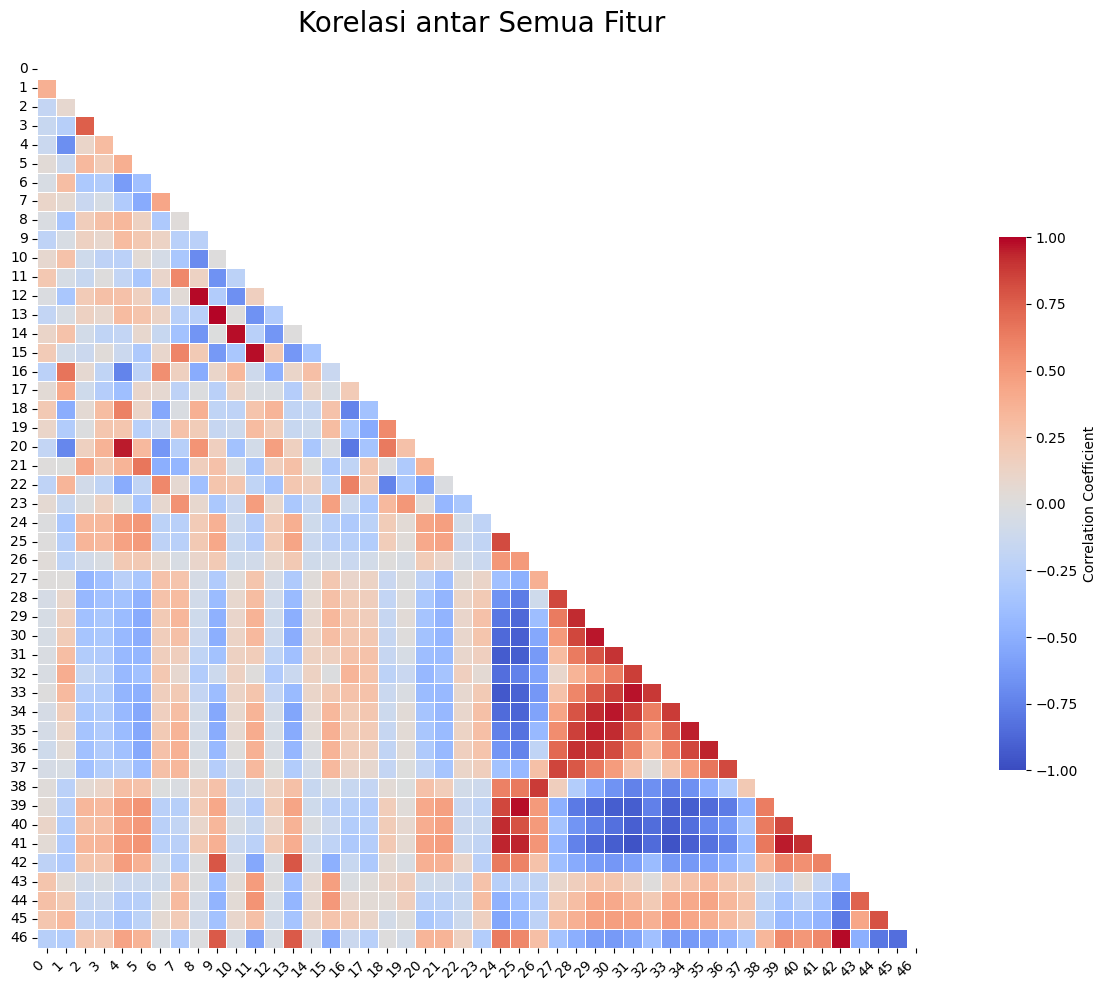

In [28]:
all_corr_mtx = all_feature_X_train.corr(method='pearson')
mask = np.triu(np.ones_like(all_corr_mtx, dtype=bool))
plt.figure(figsize=(15, 10))

# 4. Tampilkan Heatmap
sns.heatmap(
    all_corr_mtx,        # Data korelasi
    mask=mask,          # Gunakan mask segitiga
    cmap='coolwarm',    # Warna: Merah (Positif), Biru (Negatif)
    vmax=1,             # Batas atas nilai warna
    vmin=-1,            # Batas bawah nilai warna
    center=0,           # Titik tengah (warna putih/netral)
    square=True,        # Pastikan setiap sel berbentuk kotak
    linewidths=.5,      # Garis pemisah antar kotak
    annot=False,        # False agar tidak penuh angka (jika fitur sedikit, bisa True)
    cbar_kws={"shrink": .6, "label": "Correlation Coefficient"} # Pengaturan legend warna
)

# 5. Atur Label dan Judul
plt.title('Korelasi antar Semua Fitur', fontsize=20, pad=20)
plt.xticks(fontsize=10, rotation=45, ha='right') # Memiringkan label x agar terbaca
plt.yticks(fontsize=10)

# 6. Tampilkan Plot
plt.tight_layout()
plt.show()

## Standarisasi, PCA & Pelatihan Model
Standarisasi dilakukan agar model dapat lebih tepat dalam menginterpretasikan fitur tersebut. PCA digunakan sebagai metode yang dapat membantu efisiensi model sehingga model tidak perlu memproses input yang besar.

In [34]:
pipeline = make_pipeline(StandardScaler(), LDA(), SVC())

param_grid = {
    'lineardiscriminantanalysis__n_components': [4],
    'svc__C': [0.1, 1, 10, 100],
    'svc__gamma': [0.001, 0.01, 0.1, 1],
    'svc__kernel': ['rbf'],
}

sgkf = StratifiedGroupKFold(N_SPLITS, True, 42)
score_list = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
grid_search = GridSearchCV(pipeline, param_grid, cv=sgkf, scoring=score_list, refit='f1_macro')

In [41]:
def get_fit_result(fit_result):
    pd_fit_result = pd.DataFrame(fit_result.cv_results_)
    return pd_fit_result.sort_values('rank_test_f1_macro').head()[[
        'mean_fit_time',
        'std_fit_time',
        'mean_score_time',
        'std_score_time',
        'param_lineardiscriminantanalysis__n_components',
        'param_svc__C',
        'param_svc__gamma',
        'param_svc__kernel',
        'mean_test_accuracy',
        'std_test_accuracy',
        'mean_test_precision_macro',
        'std_test_precision_macro',
        'mean_test_recall_macro',
        'std_test_recall_macro',
        'mean_test_f1_macro',
        'std_test_f1_macro',
        'rank_test_f1_macro',
]]
    
def save_fitted_scenario(fitted_scenario, best_estimator_path, report_path):
    with open(os.path.join(RESULT_DICT_PATH, f'LDA_{best_estimator_path}'), 'wb') as file:
        pickle.dump(fitted_scenario.best_estimator_, file)
    
    pd_result = get_fit_result(fitted_scenario)
    pd_result.to_csv(os.path.join(RESULT_DICT_PATH, report_path), index=False)
    return pd_result

def load_fitted_scenario(best_estimator_path, report_path):
    with open(os.path.join(RESULT_DICT_PATH, f'LDA_{best_estimator_path}'), 'rb') as model_file:
        model = pickle.load(model_file)
        
    pd_train_report = pd.read_csv(os.path.join(RESULT_DICT_PATH, report_path))
    return model, pd_train_report

In [37]:
result_momen_HSV = copy.deepcopy(grid_search.fit(momen_X_train_HSV, y_train, groups=train_group_id))

In [42]:
pd_result_momen_HSV = save_fitted_scenario(result_momen_HSV, 'momen_hsv_scenario.pkl', 'momen_hsv_scenario.csv')
pd_result_momen_HSV

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
15,5.327945,0.304923,2.970375,0.353169,4,100.0,1.0,rbf,0.960481,0.003457,0.960824,0.003527,0.960481,0.003464,0.960513,0.003446,1
11,4.083179,0.260228,3.912248,0.147112,4,10.0,1.0,rbf,0.954801,0.005361,0.955405,0.005308,0.954802,0.005370,0.954872,0.005314,2
7,3.682972,0.702588,5.139976,0.332274,4,1.0,1.0,rbf,0.936960,0.007711,0.938913,0.007777,0.936962,0.007726,0.937144,0.007679,3
14,8.903976,0.420946,6.469461,0.241045,4,100.0,0.1,rbf,0.904041,0.005641,0.909356,0.005952,0.904040,0.005659,0.904436,0.005719,4
3,7.233592,1.536035,7.986647,1.000774,4,0.1,1.0,rbf,0.901481,0.005706,0.907318,0.005819,0.901485,0.005732,0.901775,0.005539,5


In [43]:
result_momen_LAB = copy.deepcopy(grid_search.fit(momen_X_train_LAB, y_train, groups=train_group_id))

In [44]:
pd_result_momen_LAB = save_fitted_scenario(result_momen_LAB, 'momen_lab_scenario.pkl', 'momen_lab_scenario.csv')
pd_result_momen_LAB

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
11,2.989312,0.193551,2.881965,0.146986,4,10.0,1.0,rbf,0.962761,0.006110,0.963428,0.005838,0.962765,0.006102,0.962847,0.006050,1
15,3.775158,0.123279,2.194141,0.065349,4,100.0,1.0,rbf,0.962080,0.004597,0.962386,0.004737,0.962085,0.004589,0.962104,0.004644,2
7,3.680284,0.407796,4.428435,0.322210,4,1.0,1.0,rbf,0.956281,0.005146,0.957301,0.004907,0.956286,0.005139,0.956394,0.005088,3
3,8.038508,0.238585,9.455137,0.713630,4,0.1,1.0,rbf,0.922481,0.005768,0.926104,0.005007,0.922490,0.005765,0.923052,0.005493,4
14,8.615316,0.404856,5.448843,0.271275,4,100.0,0.1,rbf,0.915641,0.008641,0.920136,0.007465,0.915649,0.008622,0.916432,0.008332,5


In [45]:
result_LBP = copy.deepcopy(grid_search.fit(X_train_LBP, y_train, groups=train_group_id))

In [46]:
pd_result_LBP = save_fitted_scenario(result_LBP, 'lbp_scenario.pkl', 'lbp_scenario.csv')
pd_result_LBP

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
7,12.549704,0.655376,11.760513,0.658807,4,1.0,1.0,rbf,0.748363,0.014392,0.748271,0.013863,0.748366,0.014425,0.747082,0.014162,1
11,16.797314,0.734674,11.876957,0.522619,4,10.0,1.0,rbf,0.747763,0.011874,0.748127,0.011717,0.747766,0.011908,0.746912,0.011743,2
15,46.009482,0.692122,11.344980,0.429241,4,100.0,1.0,rbf,0.737482,0.011365,0.738108,0.011428,0.737487,0.011394,0.736870,0.011316,3
3,15.947153,0.392361,13.740281,0.338743,4,0.1,1.0,rbf,0.730722,0.012060,0.730917,0.010393,0.730729,0.012089,0.728891,0.011306,4
14,23.665368,0.530031,11.468711,0.302000,4,100.0,0.1,rbf,0.729562,0.010237,0.732921,0.008482,0.729565,0.010285,0.726182,0.010100,5


In [47]:
result_GLCM = copy.deepcopy(grid_search.fit(X_train_GLCM, y_train, groups=train_group_id))

In [48]:
pd_result_GLCM = save_fitted_scenario(result_GLCM, 'glcm_scenario.pkl', 'glcm_scenario.csv')
pd_result_GLCM

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
15,15.831437,0.560935,6.999176,0.340504,4,100.0,1.0,rbf,0.890001,0.006398,0.891630,0.006063,0.890002,0.006408,0.889805,0.006371,1
11,10.206700,0.468750,8.700628,0.322772,4,10.0,1.0,rbf,0.866441,0.006125,0.870252,0.005756,0.866440,0.006139,0.866212,0.006189,2
7,11.069769,0.277131,11.461299,0.277535,4,1.0,1.0,rbf,0.819843,0.011025,0.827786,0.008985,0.819841,0.011043,0.819516,0.010954,3
14,23.680735,0.626817,12.537909,0.489464,4,100.0,0.1,rbf,0.748001,0.005842,0.758211,0.005220,0.747999,0.005842,0.746043,0.005887,4
3,14.878521,0.545163,14.711907,0.674729,4,0.1,1.0,rbf,0.745801,0.008801,0.754195,0.007837,0.745798,0.008785,0.743974,0.008526,5


In [49]:
result_color = copy.deepcopy(grid_search.fit(color_feature_X_train, y_train, groups=train_group_id))

In [50]:
pd_result_color = save_fitted_scenario(result_color, 'color_scenario.pkl', 'color_scenario.csv')
pd_result_color

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
15,4.630778,0.440109,2.266044,0.356211,4,100.0,1.0,rbf,0.959521,0.003994,0.959940,0.004096,0.959522,0.003998,0.959568,0.004023,1
11,2.992783,0.420723,2.862225,0.464961,4,10.0,1.0,rbf,0.959481,0.003835,0.959829,0.003860,0.959484,0.003840,0.959518,0.003839,2
7,3.887883,0.291724,4.563007,0.244298,4,1.0,1.0,rbf,0.951281,0.004350,0.952152,0.004127,0.951281,0.004349,0.951442,0.004280,3
14,6.900109,0.526333,4.515872,0.453324,4,100.0,0.1,rbf,0.924281,0.006851,0.927246,0.005625,0.924287,0.006836,0.924961,0.006578,4
3,7.280717,0.220659,8.058436,0.314070,4,0.1,1.0,rbf,0.923402,0.007376,0.925945,0.006886,0.923403,0.007373,0.923878,0.007236,5


In [51]:
result_texture = copy.deepcopy(grid_search.fit(texture_feature_X_train, y_train, groups=train_group_id))

In [52]:
pd_result_texture = save_fitted_scenario(result_texture, 'texture_scenario.pkl', 'texture_scenario.csv')
pd_result_texture

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
11,12.876490,0.682226,9.472420,0.452591,4,10.0,1.0,rbf,0.816321,0.005286,0.817814,0.005962,0.816326,0.005316,0.815934,0.005643,1
7,9.817291,0.486779,9.539593,0.385789,4,1.0,1.0,rbf,0.810802,0.006028,0.812912,0.007084,0.810807,0.006063,0.810405,0.006480,2
15,29.195505,1.472463,8.472603,0.571764,4,100.0,1.0,rbf,0.808842,0.008394,0.810725,0.008462,0.808849,0.008413,0.808860,0.008431,3
3,12.671559,0.376410,11.365273,0.576960,4,0.1,1.0,rbf,0.788642,0.010276,0.790527,0.009950,0.788647,0.010307,0.788113,0.010082,4
14,18.230759,0.250926,9.572836,0.548428,4,100.0,0.1,rbf,0.787802,0.008534,0.789066,0.008336,0.787805,0.008574,0.786610,0.008757,5


In [53]:
result_all = copy.deepcopy(grid_search.fit(all_feature_X_train, y_train, groups=train_group_id))

In [54]:
pd_result_all = save_fitted_scenario(result_all, 'all_scenario.pkl', 'all_scenario.csv')
pd_result_all

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
11,4.575597,0.933500,4.124219,0.974040,4,10.0,1.0,rbf,0.930321,0.004129,0.931137,0.004018,0.930324,0.004130,0.930567,0.004086,1
7,4.368714,0.910938,5.072607,0.817186,4,1.0,1.0,rbf,0.926441,0.004446,0.927422,0.004171,0.926447,0.004446,0.926743,0.004311,2
15,6.947829,1.865261,3.605734,0.746640,4,100.0,1.0,rbf,0.925041,0.004480,0.925852,0.004171,0.925045,0.004474,0.925284,0.004374,3
3,8.656020,0.453278,8.322861,0.443182,4,0.1,1.0,rbf,0.907841,0.007674,0.909915,0.007450,0.907847,0.007672,0.908538,0.007562,4
14,5.958201,0.954220,4.263229,0.964359,4,100.0,0.1,rbf,0.903841,0.005937,0.906004,0.005700,0.903845,0.005942,0.904532,0.005840,5


In [56]:
best_model_momen_HSV, pd_result_momen_HSV = load_fitted_scenario('momen_hsv_scenario.pkl', 'momen_hsv_scenario.csv')
best_model_momen_LAB, pd_result_momen_LAB = load_fitted_scenario('momen_lab_scenario.pkl', 'momen_lab_scenario.csv')
best_model_LBP, pd_result_LBP = load_fitted_scenario('lbp_scenario.pkl', 'lbp_scenario.csv')
best_model_GLCM, pd_result_GLCM = load_fitted_scenario('glcm_scenario.pkl', 'glcm_scenario.csv')
best_model_color, pd_result_color = load_fitted_scenario('color_scenario.pkl', 'color_scenario.csv')
best_model_texture, pd_result_texture = load_fitted_scenario('texture_scenario.pkl', 'texture_scenario.csv')
best_model_all, pd_result_all = load_fitted_scenario('all_scenario.pkl', 'all_scenario.csv')

In [57]:
pd_compare_best_result = pd.concat([pd_result_momen_HSV.head(1), pd_result_momen_LAB.head(1), pd_result_LBP.head(1), pd_result_GLCM.head(1), pd_result_color.head(1), pd_result_texture.head(1), pd_result_all.head(1)])
pd_compare_best_result.sort_values('rank_test_f1_macro')

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
0,5.327945,0.304923,2.970375,0.353169,4,100.0,1.0,rbf,0.960481,0.003457,0.960824,0.003527,0.960481,0.003464,0.960513,0.003446,1
0,2.989312,0.193551,2.881965,0.146986,4,10.0,1.0,rbf,0.962761,0.006110,0.963428,0.005838,0.962765,0.006102,0.962847,0.006050,1
0,12.549704,0.655376,11.760513,0.658807,4,1.0,1.0,rbf,0.748363,0.014392,0.748271,0.013863,0.748366,0.014425,0.747082,0.014162,1
0,15.831437,0.560935,6.999176,0.340504,4,100.0,1.0,rbf,0.890001,0.006398,0.891630,0.006063,0.890002,0.006408,0.889805,0.006371,1
0,4.630778,0.440109,2.266044,0.356211,4,100.0,1.0,rbf,0.959521,0.003994,0.959940,0.004096,0.959522,0.003998,0.959568,0.004023,1
0,12.876490,0.682226,9.472420,0.452591,4,10.0,1.0,rbf,0.816321,0.005286,0.817814,0.005962,0.816326,0.005316,0.815934,0.005643,1
0,4.575597,0.933500,4.124219,0.974040,4,10.0,1.0,rbf,0.930321,0.004129,0.931137,0.004018,0.930324,0.004130,0.930567,0.004086,1


Selain performa dan waktu yang dibutuhkan untuk melatihnya, ukuran model juga digunakan sebagai pertimbangan dalam efisiensinya. Berikut ukuran dari ketujuh model tersebut.

|Model|size (KB)|
|:-:|:-:|
|momen_hsv|239|
|momen_lab|235|
|lbp|220|
|glcm|459|
|color|414|
|tekstur|343|
|all|342|

## Optimasi Model
Pada tahap ini, model dengan skenario terbaik akan dioptimasi agar hasilnya dapat lebih akurat. Berdasarkan hasil pelatihan pada ketujuh skeario maka didapatkan rentang parameter yang perlu dioptimasi, seperti pca hanya dengan varian sebesar 0.95, nilai C dari 10-100, gamma 0.1 dan 1, dan tetap dengan kernel rbf.

In [58]:
optimized_param_grid = {
    'lineardiscriminantanalysis__n_components': [4],
    'svc__C': [10, 25, 50, 100],
    'svc__gamma': [1],
    'svc__kernel': ['rbf'],
}

optimized_grid_search = GridSearchCV(pipeline, optimized_param_grid, cv=sgkf, scoring=score_list, refit='f1_macro')

In [59]:
optimized_result = optimized_grid_search.fit(all_feature_X_train, y_train, groups=train_group_id) 

In [60]:
pd_optimized_result = save_fitted_scenario(optimized_result, SVM_MODEL_PATH, 'optimized_result.csv')
pd_optimized_result

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_lineardiscriminantanalysis__n_components,param_svc__C,param_svc__gamma,param_svc__kernel,mean_test_accuracy,std_test_accuracy,mean_test_precision_macro,std_test_precision_macro,mean_test_recall_macro,std_test_recall_macro,mean_test_f1_macro,std_test_f1_macro,rank_test_f1_macro
0,4.835105,0.980559,4.664976,0.626599,4,10,1,rbf,0.930321,0.004129,0.931137,0.004018,0.930324,0.004130,0.930567,0.004086,1
1,5.109346,1.222201,4.215414,0.709825,4,25,1,rbf,0.929840,0.003080,0.930593,0.003064,0.929843,0.003071,0.930049,0.003050,2
2,6.309056,1.189498,4.039337,0.856127,4,50,1,rbf,0.927961,0.004395,0.928717,0.004106,0.927964,0.004385,0.928174,0.004299,3
3,7.178908,1.362061,3.953149,0.653485,4,100,1,rbf,0.925041,0.004480,0.925852,0.004171,0.925045,0.004474,0.925284,0.004374,4


In [61]:
best_model_optimized, pd_optimized_result = load_fitted_scenario(SVM_MODEL_PATH, 'optimized_result.csv')

## Pengujian Model
Model yang telah dioptimasi kemudian diuji menggunakan data testing yang sudah di-preprocessing sebelumnya.

                       precision    recall  f1-score   support

bacterial_leaf_blight     0.8990    0.8900    0.8945       200
                blast     0.8621    0.8750    0.8685       200
           brown_spot     0.9082    0.8900    0.8990       200
               normal     0.9510    0.9700    0.9604       200
               tungro     0.9899    0.9850    0.9875       200

             accuracy                         0.9220      1000
            macro avg     0.9220    0.9220    0.9220      1000
         weighted avg     0.9220    0.9220    0.9220      1000

Confusion Matrix for SVM:


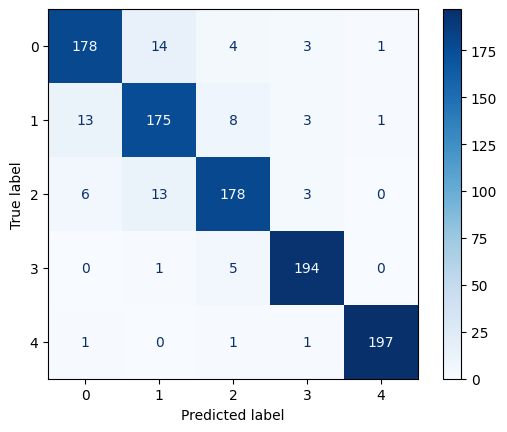

In [62]:
y_pred = best_model_optimized.predict(all_feature_X_test)
# y_pred = svm.predict(x_test_normal)
print(classification_report(y_test, y_pred, digits=4))
cm = confusion_matrix(y_test, y_pred)
print(f"Confusion Matrix for SVM:")
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
print("="*50)

## Demo Menggunakan Data baru
Demo ini bertujuan untuk menentukan ketangguhan dari model yang telah dilatih menggunakan dataset yang ada dengan data yang belum sama sekali dilihat bahkan tidak memiliki kemiripan dengan dataset yang ada, hanya ciri-ciri umum seperti background sawah dan lain-lain.

In [63]:
def extract_features_advanced(image_np_array):
    
    image = cv2.resize(image_np_array, IMG_SIZE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    normalized_image = normalizer(image, clahe)
    color_moments_hsv = calculate_color_moments(cv2.cvtColor(normalized_image, cv2.COLOR_RGB2HSV))
    color_moments_lab = calculate_color_moments(cv2.cvtColor(normalized_image, cv2.COLOR_RGB2LAB))
    lbp_feature = calculate_lbp(cv2.cvtColor(normalized_image, cv2.COLOR_RGB2GRAY))
    glcm_feature = calculate_glcm(cv2.cvtColor(normalized_image, cv2.COLOR_RGB2GRAY))
    
    result = pd.DataFrame(np.concatenate((color_moments_hsv, color_moments_lab, lbp_feature, glcm_feature)))
    result = pd.DataFrame(result.values.reshape(1,-1))
    result.columns = range(len(result.columns))
    
    return result

In [64]:
def test_model_performance(test_data_dir, model_path, classes):
    print("--- Memulai Pengujian Performa Model ---")
    start_total_time = time.time()

    # --- 1. Memuat Model dan Scaler ---
    print(f"\n[{time.strftime('%H:%M:%S', time.localtime())}] Memuat model...")
    try:
        with open(model_path, 'rb') as model_file:
            model = pickle.load(model_file)
    except FileNotFoundError as e:
        print(f"Error: {e}. Pastikan path model sudah benar.")
        return
    print(f"[{time.strftime('%H:%M:%S', time.localtime())}] Model berhasil dimuat.")

    # --- 2. Mengumpulkan Path dan Label Gambar Uji ---
    X_test_paths = []
    y_true_labels = []
    for class_name in classes:
        class_path = os.path.join(test_data_dir, class_name)
        if not os.path.isdir(class_path):
            print(f"Peringatan: Folder '{class_path}' tidak ditemukan. Lewati.")
            continue
        for img_name in os.listdir(class_path):
            if img_name.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.webp')):
                X_test_paths.append(os.path.join(class_path, img_name))
                y_true_labels.append(class_name)
    
    if not X_test_paths:
        print("Error: Tidak ada gambar yang ditemukan di direktori uji.")
        return

    # --- 3. Melakukan Prediksi dan Mengukur Waktu per Tahap ---
    y_pred_labels = []
    
    total_time_load_img = 0
    total_time_extract_feat = 0
    total_time_predict = 0

    print(f"\n[{time.strftime('%H:%M:%S', time.localtime())}] Memulai loop prediksi untuk {len(X_test_paths)} gambar...")

    for i, img_path in enumerate(X_test_paths):
        # Memuat gambar
        start_stage = time.time()
        img = cv2.imread(img_path)
        end_stage = time.time()
        total_time_load_img += (end_stage - start_stage)
        
        # Preprocessing dan ekstraksi fitur
        start_stage = time.time()
        features = extract_features_advanced(img)
        end_stage = time.time()
        total_time_extract_feat += (end_stage - start_stage)
        
        # Prediksi
        start_stage = time.time()
        prediction = model.predict(features)
        y_pred_labels.append(prediction[0])
        end_stage = time.time()
        total_time_predict += (end_stage - start_stage)

        if (i + 1) % 100 == 0 or (i + 1) == len(X_test_paths):
            print(f"[{time.strftime('%H:%M:%S', time.localtime())}] Selesai memproses {i + 1}/{len(X_test_paths)} gambar.")

    end_total_time = time.time()
    total_duration = end_total_time - start_total_time

    # --- 4. Menampilkan Hasil ---
    print("\n--- Hasil Evaluasi ---")
    accuracy = accuracy_score(y_true_labels, y_pred_labels)
    print(f"Akurasi Prediksi Keseluruhan: {accuracy:.4f}")
    print(classification_report(y_true_labels, y_pred_labels, digits=4))

    print("\n--- Ringkasan Durasi Waktu ---")
    print(f"Total Waktu Keseluruhan: {total_duration:.4f} detik")
    print(f"Total Gambar Dites: {len(X_test_paths)}")
    print(f"\nDurasi Rata-rata per Gambar:")
    print(f"  - Memuat Gambar: {total_time_load_img / len(X_test_paths):.6f} detik")
    print(f"  - Ekstraksi Fitur: {total_time_extract_feat / len(X_test_paths):.6f} detik")
    print(f"  - Prediksi Model: {total_time_predict / len(X_test_paths):.6f} detik")
    
    cm = confusion_matrix(y_true_labels, y_pred_labels)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap='Blues')

--- Memulai Pengujian Performa Model ---

[08:09:14] Memuat model...
[08:09:14] Model berhasil dimuat.

[08:09:14] Memulai loop prediksi untuk 67 gambar...
[08:09:30] Selesai memproses 67/67 gambar.

--- Hasil Evaluasi ---
Akurasi Prediksi Keseluruhan: 0.7164
                       precision    recall  f1-score   support

bacterial_leaf_blight     0.0000    0.0000    0.0000         0
                blast     0.0000    0.0000    0.0000         0
           brown_spot     0.0000    0.0000    0.0000         0
               normal     1.0000    0.7164    0.8348        67

             accuracy                         0.7164        67
            macro avg     0.2500    0.1791    0.2087        67
         weighted avg     1.0000    0.7164    0.8348        67


--- Ringkasan Durasi Waktu ---
Total Waktu Keseluruhan: 15.7480 detik
Total Gambar Dites: 67

Durasi Rata-rata per Gambar:
  - Memuat Gambar: 0.133948 detik
  - Ekstraksi Fitur: 0.096099 detik
  - Prediksi Model: 0.004938 detik


C:\Users\myytc\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\myytc\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\myytc\AppData\Roaming\Python\Python312\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape

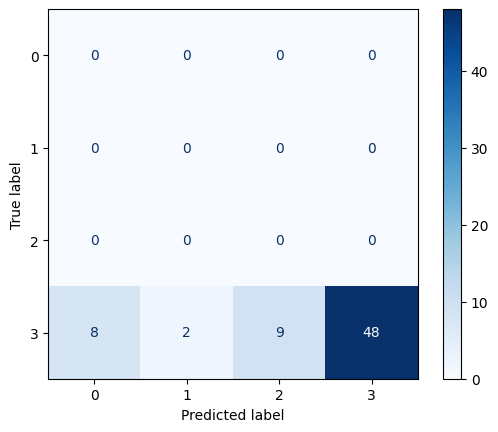

In [67]:
test_model_performance(BLIND_TEST_IMAGES_PATH, os.path.join(RESULT_DICT_PATH, f'LDA_{SVM_MODEL_PATH}'), LABELS)